# Inspect and analyze a DCDM Ly-alpha campaign

This notebook reads one completed campaign directory. It does not run CLASS, SPT or nuisance fits. It first verifies campaign completeness and then performs the scientific post-processing of the sampled $(\tau,\epsilon)$ profile-likelihood surface. It reports the discrete grid best fit, constructs paper-style likelihood maps, and audits the distance of every nuisance parameter from its numerical bounds. Contour interpolation is used only for visualization; quoted minima always refer to sampled grid points.

In [23]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

def find_project_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'lyalpha_pt').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the lyalpha_one_loop project root.')

PROJECT_ROOT = find_project_root()
CAMPAIGN_DIR = PROJECT_ROOT / 'runs/dcdm/dcdm_paper_grid_v1'
LCDM_ONE_LOOP_CHI2 = 193.105787  # Matching production LCDM reference
PUBLISHED_LCDM_ONE_LOOP_CHI2 = 192.89
PUBLISHED_DCDM_BEST_CHI2 = 189.77
EXCLUSION_DELTA_CHI2 = 3.841  # Paper convention relative to LCDM
ALLOWED_2D_DELTA_CHI2 = 5.991  # 95% region relative to the grid minimum
BOUNDARY_FRACTION = 0.05
SAVE_OUTPUTS = True
OUTPUT_DIR = CAMPAIGN_DIR / 'analysis'

print('Project:', PROJECT_ROOT)
print('Campaign:', CAMPAIGN_DIR)
print('LCDM production reference:', LCDM_ONE_LOOP_CHI2)
print('Nuisance-bound warning threshold:', f'{100 * BOUNDARY_FRACTION:.1f}%')

Project: /home/2/ks405818/Master/lyalpha_one_loop
Campaign: /home/2/ks405818/Master/lyalpha_one_loop/runs/dcdm/dcdm_paper_grid_v1
LCDM production reference: 193.105787
Nuisance-bound warning threshold: 5.0%


## Load the manifest and completed fits

In [24]:
manifest = pd.read_csv(CAMPAIGN_DIR / 'manifest.csv')
rows = []
nuisance_rows = []
for record in manifest.to_dict(orient='records'):
    point_id = record['point_id']
    theory_file = CAMPAIGN_DIR / 'theory' / f'{point_id}.npz'
    fit_file = CAMPAIGN_DIR / 'fits' / f'{point_id}.json'
    theory_done = CAMPAIGN_DIR / 'status/theory' / f'{point_id}.done.json'
    fit_done = CAMPAIGN_DIR / 'status/fit' / f'{point_id}.done.json'
    fit_failed = CAMPAIGN_DIR / 'status/fit' / f'{point_id}.failed.json'
    row = {
        **record,
        'theory_complete': theory_file.is_file() and theory_done.is_file(),
        'fit_complete': fit_file.is_file() and fit_done.is_file(),
        'fit_failed': fit_failed.is_file(),
        'chi2_linear': np.nan,
        'chi2_one_loop': np.nan,
        'delta_chi2_loop_minus_linear': np.nan,
        'near_bound_one_loop': np.nan,
        'near_bound_5pct': np.nan,
        'minimum_bound_distance': np.nan,
        'optimizer_success': np.nan,
        'multistart_chi2_range': np.nan,
        'cutoff_delta_chi2_20_minus_10': np.nan,
        'refit_strategy': None,
        'refit_selected_source_point': None,
        'refit_selected_candidate_kind': None,
        'refit_candidate_count': np.nan,
        'refit_gain_over_best_imported': np.nan,
    }
    if fit_file.is_file():
        payload = json.loads(fit_file.read_text())
        row['refit_strategy'] = payload.get('refit_strategy')
        fits = payload.get('fits', {})
        if 'linear' in fits:
            row['chi2_linear'] = fits['linear']['chi2']
        if 'one_loop' in fits:
            one_loop = fits['one_loop']
            row['chi2_one_loop'] = float(one_loop['chi2'])
            row['optimizer_success'] = bool(one_loop.get('optimizer_success', False))
            diagnostics = one_loop.get('boundary_diagnostics', [])
            distances = [
                float(item['relative_distance_to_nearest_bound'])
                for item in diagnostics
            ]
            row['near_bound_one_loop'] = any(
                item.get('near_bound', False) for item in diagnostics
            )
            if distances:
                row['minimum_bound_distance'] = min(distances)
                row['near_bound_5pct'] = min(distances) <= BOUNDARY_FRACTION
            multistart = np.asarray(one_loop.get('multistart_chi2', []), dtype=float)
            if multistart.size:
                row['multistart_chi2_range'] = float(multistart.max() - multistart.min())
            continuation = one_loop.get('cutoff_continuation', [])
            cutoff_chi2 = {
                float(item['k_uv_cut_hmpc']): float(item['chi2'])
                for item in continuation
            }
            if 10.0 in cutoff_chi2 and 20.0 in cutoff_chi2:
                row['cutoff_delta_chi2_20_minus_10'] = (
                    cutoff_chi2[20.0] - cutoff_chi2[10.0]
                )
            selected = one_loop.get('neighbour_refit_selected_source', {})
            row['refit_selected_source_point'] = selected.get('source_point_id')
            row['refit_selected_candidate_kind'] = selected.get('candidate_kind')
            audit = payload.get('neighbour_refit_audit', {}).get('one_loop', {})
            candidates = audit.get('candidates', [])
            if candidates:
                row['refit_candidate_count'] = len(candidates)
                imported = [
                    float(item['chi2']) for item in candidates
                    if item.get('candidate_kind') == 'imported'
                ]
                if imported:
                    row['refit_gain_over_best_imported'] = (
                        min(imported) - row['chi2_one_loop']
                    )
            for item in diagnostics:
                lower = float(item['lower'])
                upper = float(item['upper'])
                value = float(item['value'])
                span = upper - lower
                nuisance_rows.append({
                    'point_id': point_id,
                    'tau_gyr': float(record['tau_gyr']),
                    'epsilon_dcdm': float(record['epsilon_dcdm']),
                    'parameter': item['parameter'],
                    'value': value,
                    'lower': lower,
                    'upper': upper,
                    'distance_from_lower': (value - lower) / span,
                    'distance_from_upper': (upper - value) / span,
                    'relative_distance_to_nearest_bound': float(
                        item['relative_distance_to_nearest_bound']
                    ),
                    'near_bound_1pct_saved': bool(item.get('near_bound', False)),
                    'near_bound_5pct': bool(
                        item['relative_distance_to_nearest_bound']
                        <= BOUNDARY_FRACTION
                    ),
                })
        row['delta_chi2_loop_minus_linear'] = payload.get(
            'delta_chi2_one_loop_minus_linear', np.nan
        )
    rows.append(row)

results = pd.DataFrame(rows).sort_values('index').reset_index(drop=True)
nuisance = pd.DataFrame(nuisance_rows)
display(results.head())

,index,point_id,active,grid_level,tau_gyr,Gamma_dcdm,epsilon_dcdm,model_json,model_hash,theory_complete,...,near_bound_5pct,minimum_bound_distance,optimizer_success,multistart_chi2_range,cutoff_delta_chi2_20_minus_10,refit_strategy,refit_selected_source_point,refit_selected_candidate_kind,refit_candidate_count,refit_gain_over_best_imported
0,0,dcdm_tau1_eps0p0001,1,1,1,977.792222,0.00010,models/dcdm_tau1_eps0p0001.json,850d70215bd7a23ef1b149b97ea9c9d888d5f57b04d0f7...,True,...,False,0.150042,True,NaN,NaN,target_and_eight_grid_neighbours,dcdm_tau1_eps0p0001,imported,16,0.000000e+00
1,1,dcdm_tau1_eps0p00015,1,1,1,977.792222,0.00015,models/dcdm_tau1_eps0p00015.json,e56cdff1f609d0a1000dffcd0d002f6eecc4d5c68642a2...,True,...,False,0.145532,True,0.071038,NaN,target_and_eight_grid_neighbours,dcdm_tau2_eps0p00015,locally_refined,24,1.421085e-13
2,2,dcdm_tau1_eps0p0002,1,1,1,977.792222,0.00020,models/dcdm_tau1_eps0p0002.json,99c5f8c536fc2d19d9f6080cc4b5bde2f68c14a98a98f8...,True,...,False,0.161629,True,0.081692,NaN,target_and_eight_grid_neighbours,dcdm_tau1_eps0p00015,locally_refined,24,5.115908e-13
3,3,dcdm_tau1_eps0p0003,1,1,1,977.792222,0.00030,models/dcdm_tau1_eps0p0003.json,65fce76e3967bb0a55b0d186b3c68cef5b46df5d260275...,True,...,False,0.253284,True,NaN,NaN,target_and_eight_grid_neighbours,dcdm_tau1_eps0p0003,imported,24,0.000000e+00
4,4,dcdm_tau1_eps0p0004,1,1,1,977.792222,0.00040,models/dcdm_tau1_eps0p0004.json,66f47ba3afc23e7d3e93954d26fb2acbeab8fa2f7fb1f5...,True,...,False,0.158842,True,NaN,NaN,target_and_eight_grid_neighbours,dcdm_tau1_eps0p0004,imported,24,0.000000e+00


## Campaign status and best-fit table

In [25]:
status = pd.Series({
    'active points': int(results['active'].astype(bool).sum()),
    'theory complete': int(results['theory_complete'].sum()),
    'fit complete': int(results['fit_complete'].sum()),
    'fit failed': int(results['fit_failed'].sum()),
})
display(status.to_frame('count'))

completed = results.dropna(subset=['chi2_one_loop']).copy()
completed['delta_chi2_vs_lcdm'] = completed['chi2_one_loop'] - LCDM_ONE_LOOP_CHI2
completed['delta_chi2_vs_published_lcdm'] = (
    completed['chi2_one_loop'] - PUBLISHED_LCDM_ONE_LOOP_CHI2
)
completed['delta_chi2_from_grid_minimum'] = (
    completed['chi2_one_loop'] - completed['chi2_one_loop'].min()
)
completed['delta_chi2_vs_published_best'] = (
    completed['chi2_one_loop'] - PUBLISHED_DCDM_BEST_CHI2
)
completed['log10_gamma_gyr_inverse'] = -np.log10(completed['tau_gyr'])
completed['log10_epsilon'] = np.log10(completed['epsilon_dcdm'])
completed['allowed_95pct_from_grid_minimum'] = (
    completed['delta_chi2_from_grid_minimum'] <= ALLOWED_2D_DELTA_CHI2
)

if not (status['active points'] == status['theory complete'] == status['fit complete']):
    print('WARNING: the active campaign is not fully complete.')
columns = [
    'point_id', 'tau_gyr', 'epsilon_dcdm', 'chi2_one_loop',
    'delta_chi2_vs_lcdm', 'delta_chi2_loop_minus_linear',
    'minimum_bound_distance', 'near_bound_one_loop', 'near_bound_5pct',
    'optimizer_success', 'multistart_chi2_range',
    'refit_selected_source_point', 'refit_selected_candidate_kind',
    'refit_gain_over_best_imported',
]
display(completed.nsmallest(15, 'chi2_one_loop')[columns])

if not completed.empty:
    best = completed.loc[completed['chi2_one_loop'].idxmin()]
    print(f"Best point: {best['point_id']}")
    print(f"chi2_one_loop = {best['chi2_one_loop']:.6f}")
    print(f"Delta chi2 versus production LCDM = {best['delta_chi2_vs_lcdm']:.6f}")
    print(f"Published best chi2 = {PUBLISHED_DCDM_BEST_CHI2:.6f}")
    print(
        'Difference between our grid minimum and the published minimum = '
        f"{best['chi2_one_loop'] - PUBLISHED_DCDM_BEST_CHI2:+.6f}"
    )

,count
active points,644
theory complete,644
fit complete,644
fit failed,0


,point_id,tau_gyr,epsilon_dcdm,chi2_one_loop,delta_chi2_vs_lcdm,delta_chi2_loop_minus_linear,minimum_bound_distance,near_bound_one_loop,near_bound_5pct,optimizer_success,multistart_chi2_range,refit_selected_source_point,refit_selected_candidate_kind,refit_gain_over_best_imported
460,dcdm_tau40_eps0p006,40,0.006,189.906473,-3.199314,NaN,0.287329,False,False,True,NaN,dcdm_tau40_eps0p006,imported,0.000000e+00
461,dcdm_tau40_eps0p008,40,0.008,189.963995,-3.141792,NaN,0.288635,False,False,True,0.000000e+00,dcdm_tau50_eps0p008,locally_refined,2.842171e-14
488,dcdm_tau50_eps0p006,50,0.006,190.068118,-3.037669,NaN,0.289057,False,False,True,2.557954e-13,dcdm_tau50_eps0p004,locally_refined,1.421085e-13
489,dcdm_tau50_eps0p008,50,0.008,190.116633,-2.989154,NaN,0.290084,False,False,True,0.000000e+00,dcdm_tau80_eps0p008,locally_refined,5.684342e-14
432,dcdm_tau30_eps0p006,30,0.006,190.156702,-2.949085,NaN,0.284344,False,False,True,3.681595e-03,dcdm_tau27_eps0p004,locally_refined,1.136868e-13
433,dcdm_tau30_eps0p008,30,0.008,190.264496,-2.841291,NaN,0.286134,False,False,True,1.136868e-13,dcdm_tau40_eps0p006,locally_refined,1.136868e-13
462,dcdm_tau40_eps0p01,40,0.010,190.410509,-2.695278,NaN,0.289823,False,False,True,8.526513e-14,dcdm_tau30_eps0p01,locally_refined,1.989520e-13
404,dcdm_tau27_eps0p006,27,0.006,190.478220,-2.627567,NaN,0.177090,False,False,True,6.036144e-03,dcdm_tau30_eps0p004,locally_refined,2.273737e-13
490,dcdm_tau50_eps0p01,50,0.010,190.508873,-2.596914,NaN,0.291018,False,False,True,5.684342e-14,dcdm_tau50_eps0p015,locally_refined,1.705303e-13
405,dcdm_tau27_eps0p008,27,0.008,190.629446,-2.476341,NaN,0.284988,False,False,True,2.557954e-13,dcdm_tau30_eps0p006,locally_refined,8.526513e-14


Best point: dcdm_tau40_eps0p006
chi2_one_loop = 189.906473
Delta chi2 versus production LCDM = -3.199314
Published best chi2 = 189.770000
Difference between our grid minimum and the published minimum = +0.136473


## Sampled likelihood surface

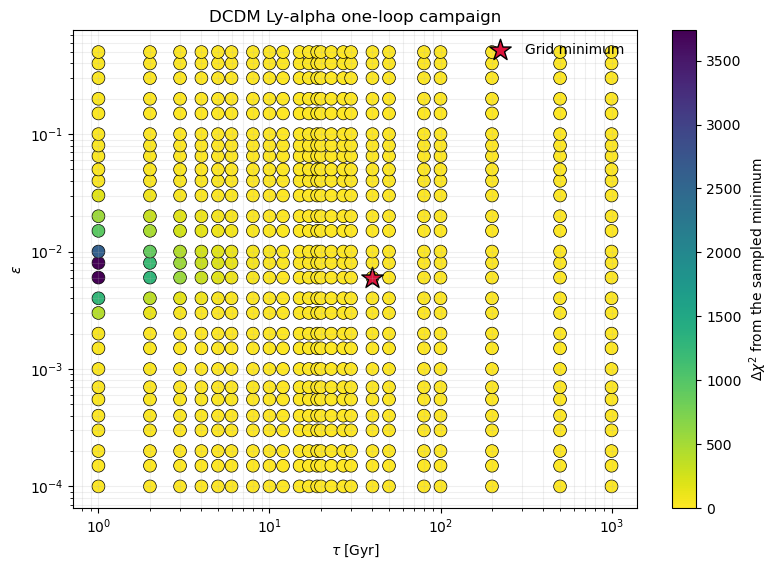

In [26]:
fig_raw, ax = plt.subplots(figsize=(8.0, 5.8))
if completed.empty:
    ax.text(0.5, 0.5, 'No completed one-loop fits', ha='center', va='center')
else:
    scatter = ax.scatter(
        completed['tau_gyr'],
        completed['epsilon_dcdm'],
        c=completed['chi2_one_loop'] - completed['chi2_one_loop'].min(),
        s=85, cmap='viridis_r', edgecolor='black', linewidth=0.5,
    )
    best = completed.loc[completed['chi2_one_loop'].idxmin()]
    ax.scatter(
        [best['tau_gyr']], [best['epsilon_dcdm']],
        marker='*', s=260, color='crimson', edgecolor='black', label='Grid minimum',
    )
    colorbar = fig_raw.colorbar(scatter, ax=ax)
    colorbar.set_label(r'$\Delta\chi^2$ from the sampled minimum')
    ax.legend(frameon=False)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\tau\;[\mathrm{Gyr}]$')
ax.set_ylabel(r'$\epsilon$')
ax.set_title('DCDM Ly-alpha one-loop campaign')
ax.grid(alpha=0.2, which='both')
fig_raw.tight_layout()
plt.show()

## Profile-likelihood conventions and paper-style maps

Two different likelihood differences answer two different questions. Following arXiv:2210.06117, $\chi^2-\chi^2_{\Lambda\mathrm{CDM}}>3.841$ defines the exclusion map relative to LCDM, while $\chi^2-\chi^2_{\min}\leq5.991$ defines the two-dimensional 95% region around the DCDM best fit. The surfaces below use linear interpolation in $(\log_{10}\Gamma,\log_{10}\epsilon)$ only to draw contours.

In [27]:
if completed.empty:
    raise RuntimeError('No completed one-loop fits are available.')

x_grid = np.sort(completed['log10_gamma_gyr_inverse'].unique())
y_grid = np.sort(completed['log10_epsilon'].unique())

def regular_grid(column):
    table = completed.pivot(
        index='log10_epsilon',
        columns='log10_gamma_gyr_inverse',
        values=column,
    ).reindex(index=y_grid, columns=x_grid)
    values = table.to_numpy(dtype=float)
    expected = (len(y_grid), len(x_grid))
    if values.shape != expected or not np.isfinite(values).all():
        raise RuntimeError(
            f'Incomplete regular grid for {column}: '
            f'shape={values.shape}, expected={expected}, '
            f'missing={np.isnan(values).sum()}.'
        )
    return values

def interpolate_surface(values, nx=500, ny=500):
    x_dense = np.linspace(x_grid.min(), x_grid.max(), nx)
    y_dense = np.linspace(y_grid.min(), y_grid.max(), ny)
    xx, yy = np.meshgrid(x_dense, y_dense)
    interpolator = RegularGridInterpolator(
        (y_grid, x_grid), values, method='linear', bounds_error=False
    )
    dense = interpolator(np.column_stack([yy.ravel(), xx.ravel()]))
    return x_dense, y_dense, dense.reshape(yy.shape)

grid_delta_min = regular_grid('delta_chi2_from_grid_minimum')
grid_delta_lcdm = regular_grid('delta_chi2_vs_lcdm')
x_dense, y_dense, delta_min_dense = interpolate_surface(grid_delta_min)
_, _, delta_lcdm_dense = interpolate_surface(grid_delta_lcdm)

best = completed.loc[completed['chi2_one_loop'].idxmin()]
best_x = float(best['log10_gamma_gyr_inverse'])
best_y = float(best['log10_epsilon'])
published_x = -np.log10(40.0)
published_y = np.log10(0.006)

print(f'Grid shape: {len(x_grid)} x {len(y_grid)} = {grid_delta_min.size}')
print(f'Grid best fit: log10(Gamma/Gyr^-1)={best_x:.6f}, log10(epsilon)={best_y:.6f}')

Grid shape: 23 x 28 = 644
Grid best fit: log10(Gamma/Gyr^-1)=-1.602060, log10(epsilon)=-2.221849


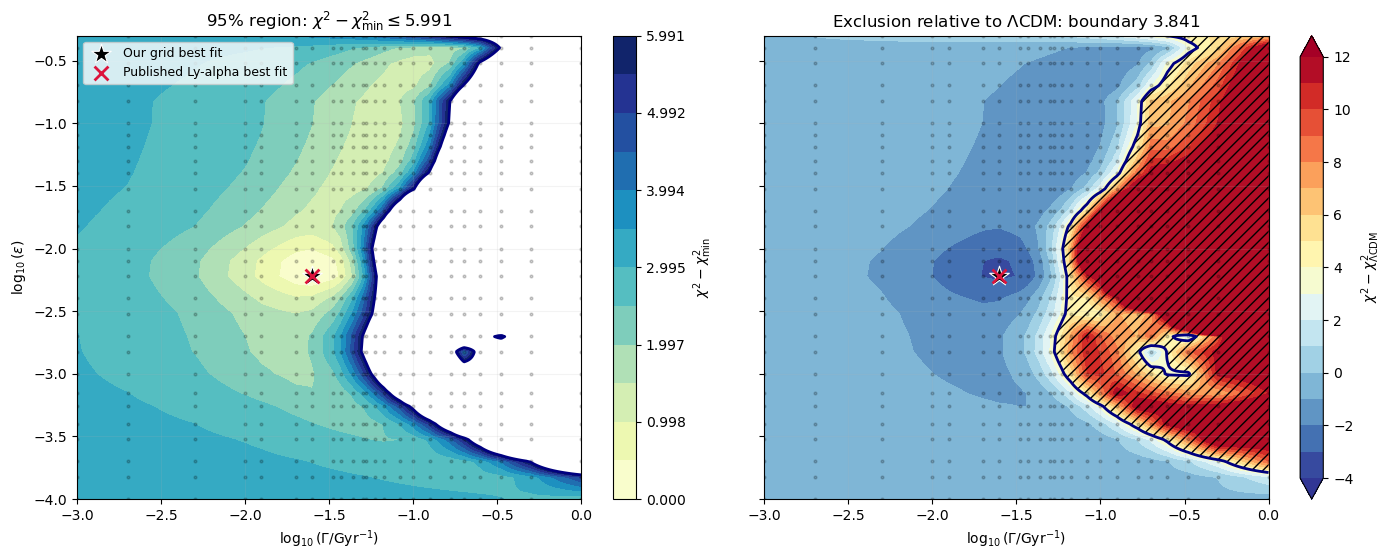

In [28]:
fig_likelihood, axes = plt.subplots(1, 2, figsize=(14.2, 5.7), sharex=True, sharey=True)

allowed_display = np.ma.masked_where(
    delta_min_dense > ALLOWED_2D_DELTA_CHI2, delta_min_dense
)
levels_allowed = np.linspace(0.0, ALLOWED_2D_DELTA_CHI2, 13)
filled_allowed = axes[0].contourf(
    x_dense, y_dense, allowed_display, levels=levels_allowed,
    cmap='YlGnBu', extend='neither',
)
axes[0].contour(
    x_dense, y_dense, delta_min_dense,
    levels=[ALLOWED_2D_DELTA_CHI2], colors='navy', linewidths=2.0,
)
axes[0].set_title(r'95% region: $\chi^2-\chi^2_{\min}\leq5.991$')
colorbar_allowed = fig_likelihood.colorbar(filled_allowed, ax=axes[0])
colorbar_allowed.set_label(r'$\chi^2-\chi^2_{\min}$')

lcdm_display = np.clip(delta_lcdm_dense, -4.0, 12.0)
filled_lcdm = axes[1].contourf(
    x_dense, y_dense, lcdm_display,
    levels=np.linspace(-4.0, 12.0, 17), cmap='RdYlBu_r', extend='both',
)
axes[1].contour(
    x_dense, y_dense, delta_lcdm_dense,
    levels=[EXCLUSION_DELTA_CHI2], colors='navy', linewidths=2.0,
)
axes[1].contourf(
    x_dense, y_dense, delta_lcdm_dense,
    levels=[EXCLUSION_DELTA_CHI2, np.nanmax(delta_lcdm_dense) + 1.0],
    colors='none', hatches=['///'],
)
axes[1].set_title(r'Exclusion relative to $\Lambda$CDM: boundary $3.841$')
colorbar_lcdm = fig_likelihood.colorbar(filled_lcdm, ax=axes[1])
colorbar_lcdm.set_label(r'$\chi^2-\chi^2_{\Lambda\mathrm{CDM}}$')

for ax in axes:
    ax.scatter(
        completed['log10_gamma_gyr_inverse'], completed['log10_epsilon'],
        s=4, color='black', alpha=0.18, rasterized=True,
    )
    ax.scatter(
        [best_x], [best_y], marker='*', s=220, color='black',
        edgecolor='white', linewidth=0.8, label='Our grid best fit', zorder=6,
    )
    ax.scatter(
        [published_x], [published_y], marker='x', s=100, color='crimson',
        linewidth=2.0, label='Published Ly-alpha best fit', zorder=6,
    )
    ax.set_xlabel(r'$\log_{10}(\Gamma/\mathrm{Gyr}^{-1})$')
    ax.grid(alpha=0.15)
axes[0].set_ylabel(r'$\log_{10}(\epsilon)$')
axes[0].legend(frameon=True, fontsize=9, loc='best')
fig_likelihood.tight_layout()
plt.show()

## Inspect nuisance parameters at the sampled minimum

In [29]:
best = completed.loc[completed['chi2_one_loop'].idxmin()]
best_fit_path = CAMPAIGN_DIR / 'fits' / f"{best['point_id']}.json"
best_payload = json.loads(best_fit_path.read_text())
best_record = best_payload['fits']['one_loop']
best_boundaries = pd.DataFrame(best_record.get('boundary_diagnostics', []))
best_boundaries['distance_percent'] = (
    100.0 * best_boundaries['relative_distance_to_nearest_bound']
)
best_boundaries['within_5pct'] = (
    best_boundaries['relative_distance_to_nearest_bound'] <= BOUNDARY_FRACTION
)
best_boundaries['nearest_bound'] = np.where(
    best_boundaries['value'] - best_boundaries['lower']
    <= best_boundaries['upper'] - best_boundaries['value'],
    'lower', 'upper',
)
display(best_boundaries[[
    'parameter', 'value', 'lower', 'upper', 'nearest_bound',
    'distance_percent', 'near_bound', 'within_5pct',
]].sort_values('distance_percent'))

print('Cutoff continuation at the grid best fit:')
display(pd.DataFrame(best_record.get('cutoff_continuation', [])))
print('Multistart chi2 values:', best_record.get('multistart_chi2', []))
print('Optimizer success:', best_record.get('optimizer_success'))
print('Optimizer message:', best_record.get('optimizer_message'))

,parameter,value,lower,upper,nearest_bound,distance_percent,near_bound,within_5pct
2,alpha_bias,-3.402735,-8.000000,8.000000,lower,28.732906,False,False
0,log_alpha_F,-4.516503,-11.512925,0.693147,upper,42.680809,False,False
5,beta_ct,64.387774,-1000.000000,1000.000000,upper,46.780611,False,False
3,beta_bias,1.383691,-15.000000,20.000000,lower,46.810546,False,False
1,beta_F,4.828173,-10.000000,20.000000,lower,49.427243,False,False
4,alpha_ct,-0.036153,-1000.000000,1000.000000,lower,49.998192,False,False


Cutoff continuation at the grid best fit:


""


Multistart chi2 values: []
Optimizer success: True
Optimizer message: grid-neighbour refit; selected fits_direct_k20:dcdm_tau40_eps0p006:imported


## Five-percent nuisance-bound audit

The fitter's stored `near_bound` flag uses a 1% threshold. Here we recompute the normalized distance to both sides of every numerical box and apply the requested 5% warning threshold. A warning is diagnostic rather than a physical prior test: it indicates that the point should be refitted with a wider box before its likelihood value is trusted. Bound warnings inside the 95% DCDM region matter more than warnings at already strongly excluded grid points.

In [30]:
likelihood_columns = completed[[
    'point_id', 'chi2_one_loop', 'delta_chi2_from_grid_minimum',
    'delta_chi2_vs_lcdm', 'allowed_95pct_from_grid_minimum',
]]
nuisance = nuisance.merge(likelihood_columns, on='point_id', how='left')

def summarize_boundaries(frame, suffix):
    summary = frame.groupby('parameter').agg(
        **{
            f'points_{suffix}': ('point_id', 'nunique'),
            f'within_1pct_{suffix}': ('near_bound_1pct_saved', 'sum'),
            f'within_5pct_{suffix}': ('near_bound_5pct', 'sum'),
            f'minimum_distance_{suffix}': (
                'relative_distance_to_nearest_bound', 'min'
            ),
            f'median_distance_{suffix}': (
                'relative_distance_to_nearest_bound', 'median'
            ),
        }
    )
    summary[f'fraction_within_5pct_{suffix}'] = (
        summary[f'within_5pct_{suffix}'] / summary[f'points_{suffix}']
    )
    return summary

summary_all = summarize_boundaries(nuisance, 'all')
summary_allowed = summarize_boundaries(
    nuisance[nuisance['allowed_95pct_from_grid_minimum']], 'allowed95'
)
boundary_summary = summary_all.join(summary_allowed, how='left')
display(boundary_summary.sort_values('minimum_distance_all'))

warnings_allowed = nuisance[
    nuisance['allowed_95pct_from_grid_minimum'] & nuisance['near_bound_5pct']
].sort_values([
    'relative_distance_to_nearest_bound', 'chi2_one_loop'
])
print(f'Five-percent warnings in the 95% DCDM region: {len(warnings_allowed)}')
display(warnings_allowed[[
    'point_id', 'tau_gyr', 'epsilon_dcdm', 'parameter', 'value',
    'lower', 'upper', 'relative_distance_to_nearest_bound',
    'delta_chi2_from_grid_minimum',
]].head(50))

,points_all,within_1pct_all,within_5pct_all,minimum_distance_all,median_distance_all,fraction_within_5pct_all,points_allowed95,within_1pct_allowed95,within_5pct_allowed95,minimum_distance_allowed95,median_distance_allowed95,fraction_within_5pct_allowed95
parameter,,,,,,,,,,,,
beta_bias,644,6,7,0.000000,0.469106,0.010870,445,0,1,0.017536,0.469400,0.002247
beta_ct,644,2,2,0.000600,0.477667,0.003106,445,2,2,0.000600,0.475470,0.004494
log_alpha_F,644,0,0,0.111420,0.424677,0.000000,445,0,0,0.363989,0.431689,0.000000
alpha_bias,644,0,0,0.181646,0.295012,0.000000,445,0,0,0.223083,0.294577,0.000000
beta_F,644,0,0,0.297894,0.494745,0.000000,445,0,0,0.454287,0.494945,0.000000
alpha_ct,644,0,0,0.490837,0.499980,0.000000,445,0,0,0.499914,0.499980,0.000000


Five-percent warnings in the 95% DCDM region: 3


,point_id,tau_gyr,epsilon_dcdm,parameter,value,lower,upper,relative_distance_to_nearest_bound,delta_chi2_from_grid_minimum
1469,dcdm_tau12_eps0p065,12.0,0.0650,beta_ct,998.799770,-1000.0,1000.0,0.000600,1.574933
1301,dcdm_tau10_eps0p065,10.0,0.0650,beta_ct,981.755266,-1000.0,1000.0,0.009122,2.240470
723,dcdm_tau5_eps0p0015,5.0,0.0015,beta_bias,-14.386245,-15.0,20.0,0.017536,3.763881


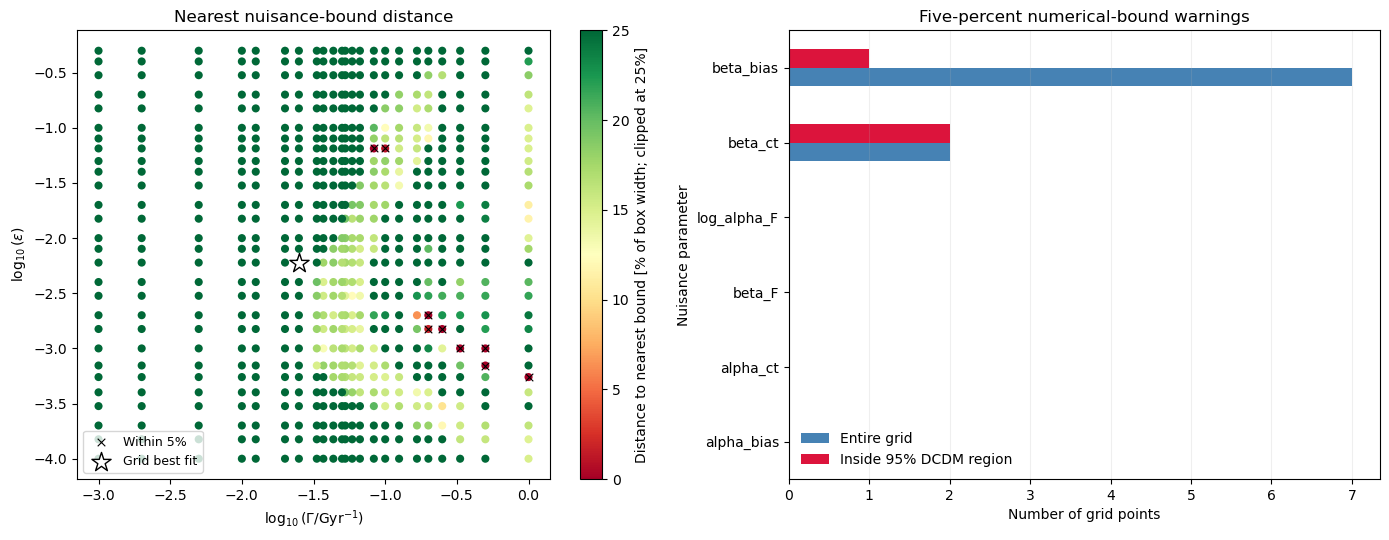

In [31]:
fig_boundaries, axes = plt.subplots(1, 2, figsize=(14.0, 5.5))

distance_percent = 100.0 * completed['minimum_bound_distance'].astype(float)
boundary_scatter = axes[0].scatter(
    completed['log10_gamma_gyr_inverse'], completed['log10_epsilon'],
    c=np.clip(distance_percent, 0.0, 25.0), s=34, cmap='RdYlGn',
    vmin=0.0, vmax=25.0, edgecolor='none', rasterized=True,
)
warning_points = completed[completed['near_bound_5pct'].astype(bool)]
axes[0].scatter(
    warning_points['log10_gamma_gyr_inverse'],
    warning_points['log10_epsilon'],
    marker='x', s=30, color='black', linewidth=0.8, label='Within 5%',
)
axes[0].scatter(
    [best_x], [best_y], marker='*', s=210, color='white',
    edgecolor='black', linewidth=1.0, label='Grid best fit', zorder=6,
)
axes[0].set_xlabel(r'$\log_{10}(\Gamma/\mathrm{Gyr}^{-1})$')
axes[0].set_ylabel(r'$\log_{10}(\epsilon)$')
axes[0].set_title('Nearest nuisance-bound distance')
axes[0].legend(frameon=True, fontsize=9)
bound_colorbar = fig_boundaries.colorbar(boundary_scatter, ax=axes[0])
bound_colorbar.set_label('Distance to nearest bound [% of box width; clipped at 25%]')

bar_table = boundary_summary[[
    'within_5pct_all', 'within_5pct_allowed95'
]].fillna(0).sort_values('within_5pct_all')
bar_table.plot.barh(ax=axes[1], color=['steelblue', 'crimson'])
axes[1].set_xlabel('Number of grid points')
axes[1].set_ylabel('Nuisance parameter')
axes[1].set_title('Five-percent numerical-bound warnings')
axes[1].legend(['Entire grid', 'Inside 95% DCDM region'], frameon=False)
axes[1].grid(axis='x', alpha=0.2)
fig_boundaries.tight_layout()
plt.show()

## Optimizer, neighbour-refit and cutoff diagnostics

In [32]:
optimizer_failures = completed[~completed['optimizer_success'].astype(bool)]
print('Optimizer failures:', len(optimizer_failures))
display(optimizer_failures[[
    'point_id', 'tau_gyr', 'epsilon_dcdm', 'chi2_one_loop'
]].head(30))

refitted = completed[completed['refit_strategy'].notna()]
print('Neighbour-refitted points:', len(refitted))
if not refitted.empty:
    print('Selected source type:')
    display(refitted['refit_selected_candidate_kind'].value_counts().to_frame('points'))
    print('Largest local improvement over every raw imported solution:')
    display(refitted.nlargest(20, 'refit_gain_over_best_imported')[[
        'point_id', 'tau_gyr', 'epsilon_dcdm', 'chi2_one_loop',
        'refit_selected_source_point', 'refit_selected_candidate_kind',
        'refit_candidate_count', 'refit_gain_over_best_imported',
    ]])

print('Largest spread among stored multistart chi2 values:')
display(completed.nlargest(20, 'multistart_chi2_range')[[
    'point_id', 'tau_gyr', 'epsilon_dcdm', 'chi2_one_loop',
    'delta_chi2_from_grid_minimum', 'multistart_chi2_range',
]])

print('Largest absolute shift along the stored kUV=10 -> 20 continuation:')
cutoff_order = completed.assign(
    absolute_cutoff_shift=completed['cutoff_delta_chi2_20_minus_10'].abs()
).nlargest(20, 'absolute_cutoff_shift')
display(cutoff_order[[
    'point_id', 'tau_gyr', 'epsilon_dcdm', 'chi2_one_loop',
    'delta_chi2_from_grid_minimum',
    'cutoff_delta_chi2_20_minus_10', 'absolute_cutoff_shift',
]])

Optimizer failures: 0


,point_id,tau_gyr,epsilon_dcdm,chi2_one_loop


Neighbour-refitted points: 644
Selected source type:


,points
refit_selected_candidate_kind,
locally_refined,499
imported,145


Largest local improvement over every raw imported solution:


,point_id,tau_gyr,epsilon_dcdm,chi2_one_loop,refit_selected_source_point,refit_selected_candidate_kind,refit_candidate_count,refit_gain_over_best_imported
96,dcdm_tau4_eps0p006,4,0.00600,489.427524,dcdm_tau4_eps0p008,locally_refined,36,22.252672
343,dcdm_tau20_eps0p001,20,0.00100,194.613175,dcdm_tau19_eps0p0015,locally_refined,36,14.761066
315,dcdm_tau19_eps0p001,19,0.00100,195.118373,dcdm_tau17_eps0p0015,locally_refined,36,13.858689
208,dcdm_tau10_eps0p006,10,0.00600,205.896435,dcdm_tau8_eps0p004,locally_refined,36,12.431712
201,dcdm_tau10_eps0p00055,10,0.00055,196.392002,dcdm_tau12_eps0p0004,locally_refined,36,9.100771
54,dcdm_tau2_eps0p4,2,0.40000,198.663449,dcdm_tau1_eps0p4,locally_refined,36,9.021644
181,dcdm_tau8_eps0p008,8,0.00800,241.135191,dcdm_tau6_eps0p006,locally_refined,36,7.762868
209,dcdm_tau10_eps0p008,10,0.00800,214.978696,dcdm_tau8_eps0p006,locally_refined,36,7.026850
75,dcdm_tau3_eps0p05,3,0.05000,204.929191,dcdm_tau2_eps0p065,locally_refined,36,6.339318
102,dcdm_tau4_eps0p04,4,0.04000,206.119305,dcdm_tau3_eps0p03,locally_refined,36,6.049464


Largest spread among stored multistart chi2 values:


,point_id,tau_gyr,epsilon_dcdm,chi2_one_loop,delta_chi2_from_grid_minimum,multistart_chi2_range
254,dcdm_tau15_eps0p0002,15,0.00020,192.666642,2.760169,0.327078
56,dcdm_tau3_eps0p0001,3,0.00010,192.913662,3.007190,0.250229
141,dcdm_tau6_eps0p00015,6,0.00015,192.697279,2.790806,0.144270
198,dcdm_tau10_eps0p0002,10,0.00020,192.568294,2.661821,0.116244
453,dcdm_tau40_eps0p00055,40,0.00055,192.163961,2.257489,0.107220
59,dcdm_tau3_eps0p0003,3,0.00030,201.351143,11.444671,0.081759
2,dcdm_tau1_eps0p0002,1,0.00020,202.025712,12.119239,0.081692
87,dcdm_tau4_eps0p0003,4,0.00030,197.459132,7.552659,0.080313
116,dcdm_tau5_eps0p0004,5,0.00040,201.035431,11.128959,0.080240
144,dcdm_tau6_eps0p0004,6,0.00040,198.161140,8.254667,0.079352


Largest absolute shift along the stored kUV=10 -> 20 continuation:


,point_id,tau_gyr,epsilon_dcdm,chi2_one_loop,delta_chi2_from_grid_minimum,cutoff_delta_chi2_20_minus_10,absolute_cutoff_shift
0,dcdm_tau1_eps0p0001,1,0.00010,192.523080,2.616607,NaN,NaN
1,dcdm_tau1_eps0p00015,1,0.00015,194.904545,4.998072,NaN,NaN
2,dcdm_tau1_eps0p0002,1,0.00020,202.025712,12.119239,NaN,NaN
3,dcdm_tau1_eps0p0003,1,0.00030,206.270959,16.364486,NaN,NaN
4,dcdm_tau1_eps0p0004,1,0.00040,204.303284,14.396812,NaN,NaN
5,dcdm_tau1_eps0p00055,1,0.00055,206.861327,16.954854,NaN,NaN
6,dcdm_tau1_eps0p0007,1,0.00070,204.100380,14.193908,NaN,NaN
7,dcdm_tau1_eps0p001,1,0.00100,206.046222,16.139749,NaN,NaN
8,dcdm_tau1_eps0p0015,1,0.00150,216.461595,26.555122,NaN,NaN
9,dcdm_tau1_eps0p002,1,0.00200,223.181356,33.274884,NaN,NaN


## Save analysis products

In [33]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    completed.sort_values('index').to_csv(
        OUTPUT_DIR / 'campaign_profile_likelihood.csv', index=False
    )
    nuisance.to_csv(
        OUTPUT_DIR / 'nuisance_boundary_diagnostics.csv', index=False
    )
    boundary_summary.to_csv(OUTPUT_DIR / 'nuisance_boundary_summary.csv')
    warnings_allowed.to_csv(
        OUTPUT_DIR / 'nuisance_warnings_inside_95pct_region.csv', index=False
    )
    best_summary = {
        'point_id': best['point_id'],
        'tau_gyr': float(best['tau_gyr']),
        'epsilon_dcdm': float(best['epsilon_dcdm']),
        'chi2_one_loop': float(best['chi2_one_loop']),
        'lcdm_reference_chi2': LCDM_ONE_LOOP_CHI2,
        'delta_chi2_vs_lcdm': float(best['delta_chi2_vs_lcdm']),
        'published_best_chi2': PUBLISHED_DCDM_BEST_CHI2,
        'minimum_nuisance_bound_distance': float(
            best['minimum_bound_distance']
        ),
        'any_nuisance_within_5pct': bool(best['near_bound_5pct']),
        'refit_strategy': best['refit_strategy'],
        'refit_selected_source_point': best['refit_selected_source_point'],
        'refit_selected_candidate_kind': best['refit_selected_candidate_kind'],
    }
    (OUTPUT_DIR / 'best_fit_summary.json').write_text(
        json.dumps(best_summary, indent=2, sort_keys=True) + '\n',
        encoding='utf-8',
    )
    fig_raw.savefig(OUTPUT_DIR / 'raw_sampled_grid.png', dpi=220, bbox_inches='tight')
    fig_likelihood.savefig(
        OUTPUT_DIR / 'dcdm_profile_likelihood_maps.png', dpi=220, bbox_inches='tight'
    )
    fig_boundaries.savefig(
        OUTPUT_DIR / 'nuisance_boundary_audit.png', dpi=220, bbox_inches='tight'
    )
    print('Saved analysis products to:', OUTPUT_DIR)

Saved analysis products to: /home/2/ks405818/Master/lyalpha_one_loop/runs/dcdm/dcdm_paper_grid_v1/analysis


## Recommended interpretation

First quote the discrete grid minimum and its nuisance-bound table. Treat the interpolated contours as a visualization of the sampled profile likelihood, not as additional likelihood evaluations. If a point inside the 95% DCDM region lies within 5% of any numerical nuisance bound, rerun that point with a wider box before finalizing the contour. Bound warnings confined to strongly excluded points are less consequential but should remain documented. Finally, compare selected production and precision theory anchors with `scripts/compare_theories.py`; a low nuisance-fit $\chi^2$ alone is not a convergence test.